# Converting data from D7/D9/D11 timecourse Seurat object to Python anndata

## Inputs
1. ../results/timescourse/timecourse-d7911-renamed-metadata.csv
2. ../results/timescourse/timecourse-d7911-renamed-counts.mtx
3. ../results/timescourse/timecourse-d7911-renamed-genes.txt
4. ../results/timescourse/timecourse-d7911-renamed-pca.csv

## Output
1. ../seurat_objects/timecourse-d7911-renamed-metadata.h5ad

In [ ]:
import os
import scanpy as sc
import anndata as ad
import scvelo as scv
import numpy as np
import pandas as pd
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix

scv.settings.verbosity = 3
scv.settings.set_figure_params('scvelo', facecolor='white', dpi=100, frameon=False)

In [ ]:
# load sparse matrix:
X = io.mmread("../results/timecourse/timecourse-d7911-renamed-counts.mtx")

In [ ]:
# create anndata object
adata = ad.AnnData(X=X.transpose().tocsr())
adata

AnnData object with n_obs × n_vars = 148750 × 29927

In [ ]:
metadata = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-metadata.csv")
integrated_umap = pd.read_csv("../results/timecourse/timecourse-d7911-integrated-umap-embeddings.csv", index_col=0)
merged_umap = pd.read_csv("../results/timecourse/timecourse-d7911-merged-umap-embeddings.csv", index_col=0)
metadata.head()

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,seurat_clusters,integrated_snn_res.0.4,cell_type,S.Score,G2M.Score,Phase,barcode,condition,genotype,time
0,T21wtGATA1D7,10896.474808,3428,7.181223,5,5,HPC - Ery bias,0.231739,-0.070994,S,T21wtGATA1D7_AAACCCAAGGTCGACA-1,T21,wtGATA1,D7
1,T21wtGATA1D7,12541.096228,4423,9.452731,9,9,HPCs,0.088562,-0.023868,S,T21wtGATA1D7_AAACCCACAGAGGGTT-1,T21,wtGATA1,D7
2,T21wtGATA1D7,7375.252885,2777,5.695975,1,1,HPC - MK bias 1,-0.155245,-0.249261,G1,T21wtGATA1D7_AAACCCACAGCCGTTG-1,T21,wtGATA1,D7
3,T21wtGATA1D7,12614.292765,4477,7.136198,8,8,MK,-0.010138,0.498942,G2M,T21wtGATA1D7_AAACCCAGTACCTATG-1,T21,wtGATA1,D7
4,T21wtGATA1D7,9829.658751,3700,8.449782,1,1,HPC - MK bias 1,0.330801,-0.071991,S,T21wtGATA1D7_AAACCCAGTAGGACTG-1,T21,wtGATA1,D7


In [ ]:
# load gene names
with open("../results/timecourse/timecourse-d7911-renamed-genes.txt", "r") as f:
    gene_names = f.read().splitlines()
gene_names[0:5]

['AL627309.1', 'AL627309.5', 'LINC01409', 'LINC01128', 'LINC00115']

In [ ]:
# set anndata observations and index obs by barcodes, var by gene names
adata.obs = metadata
adata.obs.index = adata.obs["barcode"]
adata.var.index = gene_names
adata

AnnData object with n_obs × n_vars = 148750 × 29927
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time'

In [ ]:
# load dimensional reduction:
pca = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-pca.csv")
pca.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_41,PC_42,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50
0,6.353114,6.070405,-4.090260,3.912296,-3.551785,-4.115428,4.846863,2.638363,1.060614,0.966458,...,0.122994,-0.357458,0.679639,1.342961,0.033568,-0.069827,0.389236,0.841558,0.620956,-0.380474
1,-2.382874,-1.073526,11.834473,0.490515,4.460756,2.659763,-1.457123,2.792893,-1.808399,-1.751801,...,-0.785094,0.259204,-0.546817,1.758175,2.301621,0.544455,-0.383108,-0.411654,-0.669740,1.718228
2,-7.673864,2.904968,-2.639060,-2.660269,-3.168539,-6.204685,0.849827,-4.675847,-1.776354,1.201923,...,-0.428800,-2.083072,1.684376,-0.816944,2.424118,-1.006537,1.119187,0.252606,-0.060218,-2.704998
3,-8.223620,0.854796,-1.181926,2.830106,4.114265,1.591180,0.618281,-1.704377,2.599254,-2.531468,...,0.939141,-1.434934,-1.361932,0.688121,-0.022928,-0.212692,-1.099988,-1.795285,-0.274987,0.044016
4,-8.425855,-1.752611,9.490454,2.912539,-2.677871,-6.368963,-1.999538,-0.593523,3.600142,0.251025,...,0.807237,-1.803233,0.585483,0.147529,0.559556,-0.441195,0.572830,-0.875968,-0.325235,-1.333011


In [ ]:
# set pca and umap
adata.obsm['X_pca'] = pca.to_numpy()
adata.obsm['X_umap_integrated'] = integrated_umap.loc[adata.obs_names,:].to_numpy()
adata.obsm['X_umap_merged'] = merged_umap.loc[adata.obs_names,:].to_numpy()
adata

AnnData object with n_obs × n_vars = 148750 × 29927
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'

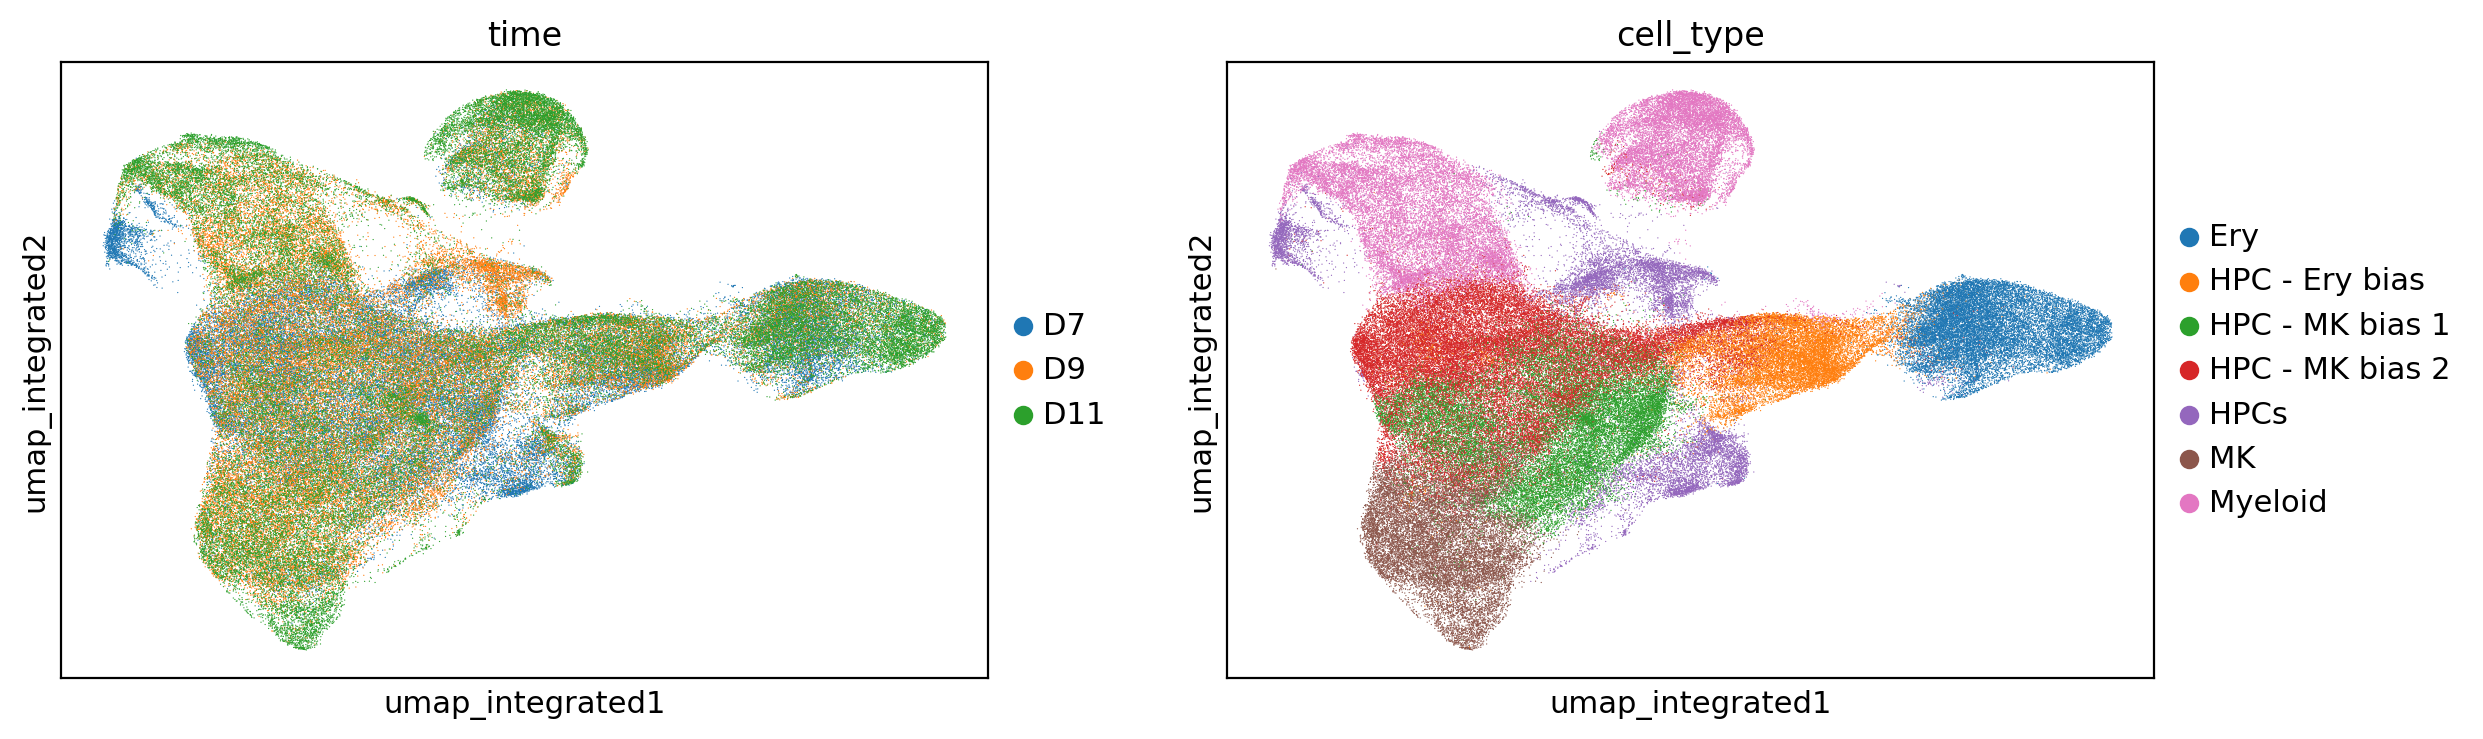

In [ ]:
cols = {"HPCs": "#cdc9c9", "HPC - MK bias 2": "thistle", "HPC - MK bias 1": "#ab82ff", "MK": "#551a8b",
        "HPC - Ery bais": "#cd6090", "Ery": "#8b0000", "Myeloid": "turquoise"}
sc.pl.embedding(
    adata,
    color=["time", "cell_type"],
    basis="umap_integrated",
    color_map="gnuplot2"
)

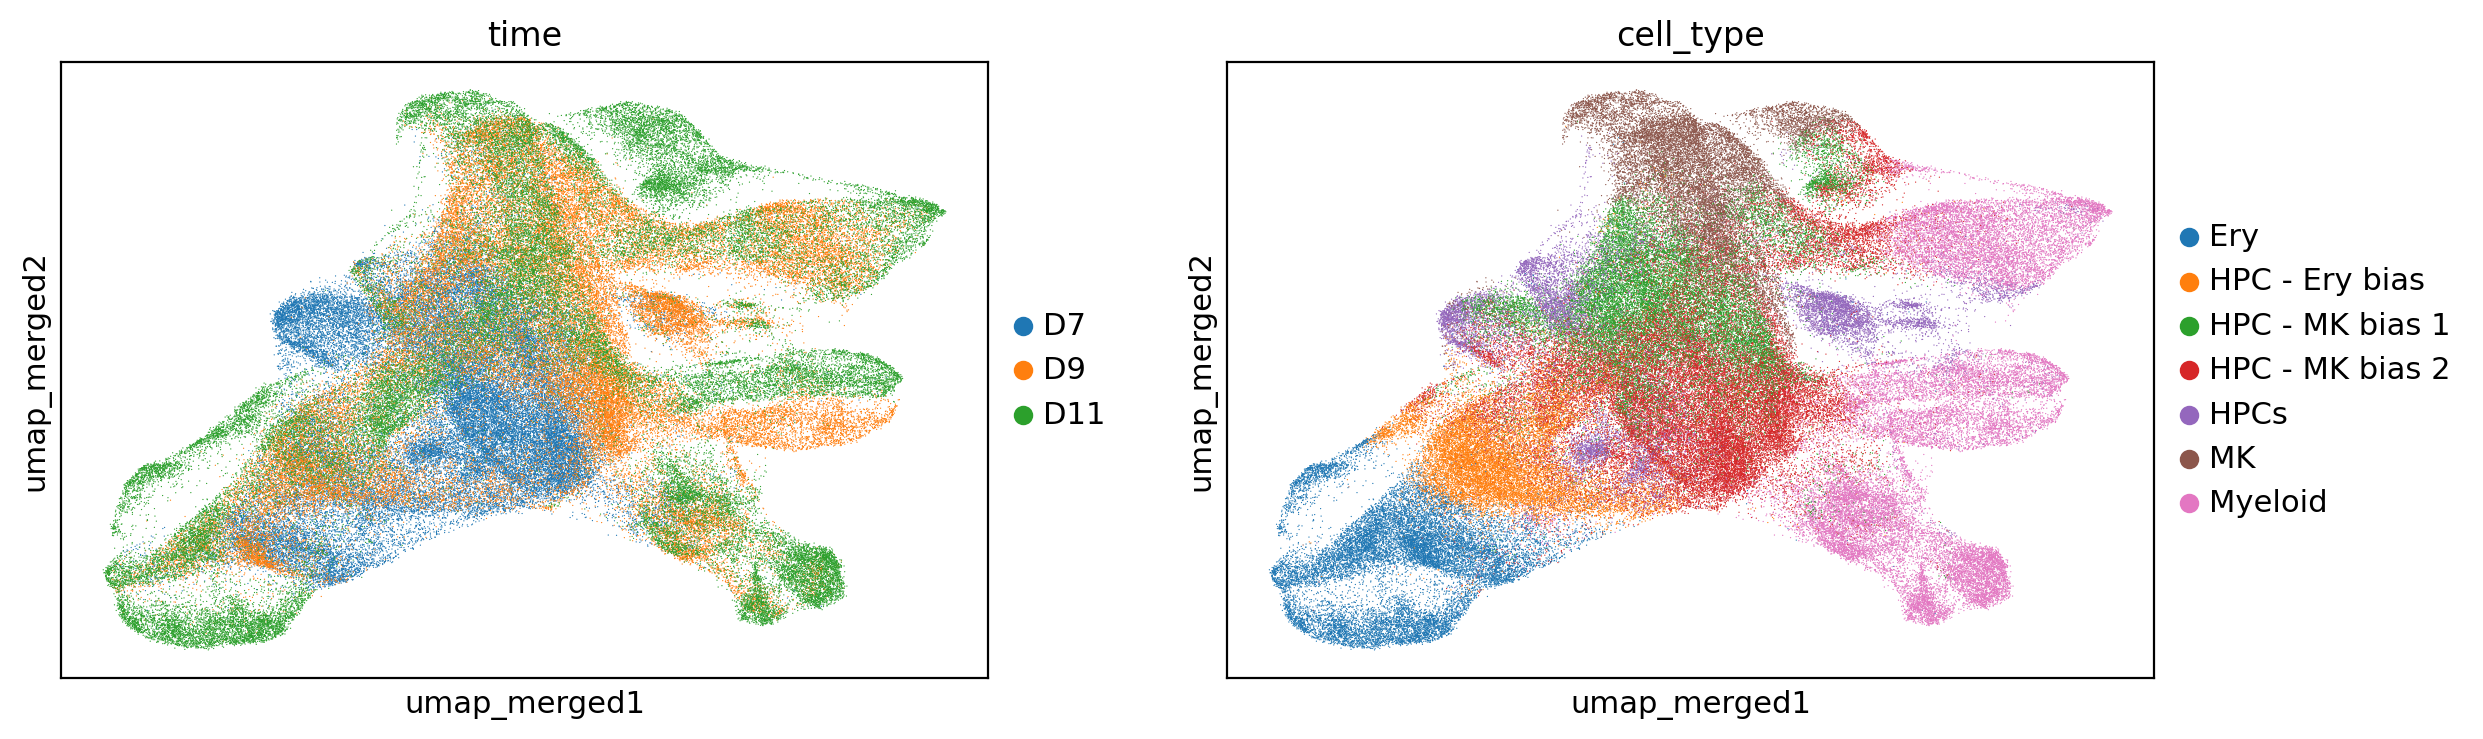

In [ ]:
cols = {"HPCs": "#cdc9c9", "HPC - MK bias 2": "thistle", "HPC - MK bias 1": "#ab82ff", "MK": "#551a8b",
        "HPC - Ery bais": "#cd6090", "Ery": "#8b0000", "Myeloid": "turquoise"}
sc.pl.embedding(
    adata,
    color=["time", "cell_type"],
    basis="umap_merged",
    color_map="gnuplot2"
)

In [ ]:
# cols = {"HPCs": "#cdc9c9", "HPC - MK bias 2": "thistle", "HPC - MK bias 1": "#ab82ff", "MK": "#551a8b",
#         "HPC - Ery bais": "#cd6090", "Ery": "#8b0000", "Myeloid": "turquoise"}

# sc.settings.figdir = "plots/pub"
# sc.pl.umap(adata, color=["cell_type"], basis='umap_integrated', palette=cols, frameon=False, save="timecourse-d7911-umap-adata.pdf")

In [ ]:
# save dataset as anndata format
adata.write("../seurat_objects/timecourse-d7911-renamed.h5ad")

In [ ]:
# reload dataset
adata = sc.read_h5ad("../seurat_objects/timecourse-d7911-renamed.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 29927
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'

In [ ]:
# load loom files for spliced/unspliced matrices for each sample:
T21wtGATA1D7 = scv.read("../data/timecourse/DS145_EM9_D7/outs/velocyto/possorted_genome_bam_Y39LU.loom", cache=True)
T21GATA1sD7 = scv.read("../data/timecourse/TMD145_SCM71_D7/outs/velocyto/possorted_genome_bam_OFG2Q.loom", cache=True)
EuploidwtGATA1D7 = scv.read("../data/timecourse/TMD145_EM331434_D7/outs/velocyto/possorted_genome_bam_VRF4A.loom", cache=True)
EuploidGATA1sD7 = scv.read("../data/timecourse/TMD145_EM3319_D7/outs/velocyto/possorted_genome_bam_59PQF.loom", cache=True)
T21wtGATA1D9 = scv.read("../data/timecourse/DS145_EM9_D9/outs/velocyto/possorted_genome_bam_WWFXK.loom", cache=True)
T21GATA1sD9 = scv.read("../data/timecourse/TMD145_SCM71_D9/outs/velocyto/possorted_genome_bam_CEA8S.loom", cache=True)
EuploidwtGATA1D9 = scv.read("../data/timecourse/TMD145_EM331434_D9/outs/velocyto/possorted_genome_bam_2KSX8.loom", cache=True)
EuploidGATA1sD9 = scv.read("../data/timecourse/TMD145_EM3319_D9/outs/velocyto/possorted_genome_bam_0P1D8.loom", cache=True)
T21wtGATA1D11 = scv.read("../data/timecourse/DS145_EM9_D11/outs/velocyto/possorted_genome_bam_GXO36.loom", cache=True)
T21GATA1sD11 = scv.read("../data/time_course/TMD145_SCM71_D11/outs/velocyto/possorted_genome_bam_EMHUH.loom", cache=True)
EuploidwtGATA1D11 = scv.read("data/timecourse/TMD145_EM331434_D11/outs/velocyto/possorted_genome_bam_RQAYU.loom", cache=True)
EuploidGATA1sD11 = scv.read("data/timecourse/TMD145_EM3319_D11/outs/velocyto/possorted_genome_bam_8Q23I.loom", cache=True)

In [ ]:
# rename barcodes in order to merge:
barcodes = ["T21wtGATA1D7_" + bc.split(":")[1] for bc in T21wtGATA1D7.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
T21wtGATA1D7.obs.index = barcodes
T21wtGATA1D7.var_names_make_unique()

barcodes = ["T21GATA1sD7_" + bc.split(":")[1] for bc in T21GATA1sD7.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
T21GATA1sD7.obs.index = barcodes
T21GATA1sD7.var_names_make_unique()

barcodes = ["EuploidwtGATA1D7_" + bc.split(":")[1] for bc in EuploidwtGATA1D7.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
EuploidwtGATA1D7.obs.index = barcodes
EuploidwtGATA1D7.var_names_make_unique()

barcodes = ["EuploidGATA1sD7_" + bc.split(":")[1] for bc in EuploidGATA1sD7.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
EuploidGATA1sD7.obs.index = barcodes
EuploidGATA1sD7.var_names_make_unique()

barcodes = ["T21wtGATA1D9_" + bc.split(":")[1] for bc in T21wtGATA1D9.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
T21wtGATA1D9.obs.index = barcodes
T21wtGATA1D9.var_names_make_unique()

barcodes = ["T21GATA1sD9_" + bc.split(":")[1] for bc in T21GATA1sD9.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
T21GATA1sD9.obs.index = barcodes
T21GATA1sD9.var_names_make_unique()

barcodes = ["EuploidwtGATA1D9_" + bc.split(":")[1] for bc in EuploidwtGATA1D9.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
EuploidwtGATA1D9.obs.index = barcodes
EuploidwtGATA1D9.var_names_make_unique()

barcodes = ["EuploidGATA1sD9_" + bc.split(":")[1] for bc in EuploidGATA1sD9.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
EuploidGATA1sD9.obs.index = barcodes
EuploidGATA1sD9.var_names_make_unique()

barcodes = ["T21wtGATA1D11_" + bc.split(":")[1] for bc in T21wtGATA1D11.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
T21wtGATA1D11.obs.index = barcodes
T21wtGATA1D11.var_names_make_unique()

barcodes = ["T21GATA1sD11_" + bc.split(":")[1] for bc in T21GATA1sD11.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
T21GATA1sD11.obs.index = barcodes
T21GATA1sD11.var_names_make_unique()

barcodes = ["EuploidwtGATA1D11_" + bc.split(":")[1] for bc in EuploidwtGATA1D11.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
EuploidwtGATA1D11.obs.index = barcodes
EuploidwtGATA1D11.var_names_make_unique()

barcodes = ["EuploidGATA1sD11_" + bc.split(":")[1] for bc in EuploidGATA1sD11.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + "-1" for bc in barcodes]
EuploidGATA1sD11.obs.index = barcodes
EuploidGATA1sD11.var_names_make_unique()


In [ ]:
# concatenate all looms
ldata = T21wtGATA1D7.concatenate([T21GATA1sD7, EuploidwtGATA1D7, EuploidGATA1sD7,
                                  T21wtGATA1D9, T21GATA1sD9, EuploidwtGATA1D9, EuploidGATA1sD9,
                                  T21wtGATA1D11, T21GATA1sD11, EuploidwtGATA1D11, EuploidGATA1sD11])
ldata

AnnData object with n_obs × n_vars = 173281 × 36601
    obs: 'batch'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [ ]:
# merge matrices adata and ldata
adata = scv.utils.merge(adata, ldata)
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

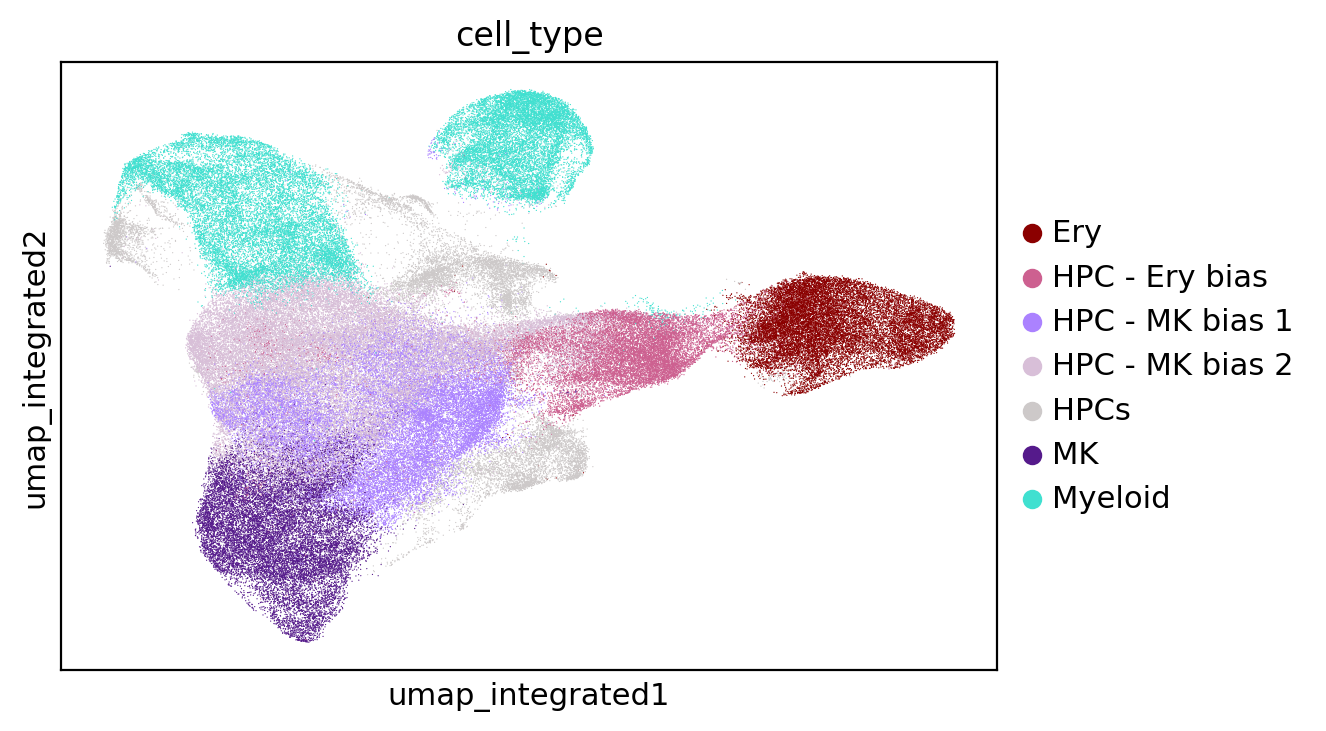

In [ ]:
cols = {"HPCs": "#cdc9c9", "HPC - MK bias 2": "thistle", "HPC - MK bias 1": "#ab82ff", "MK": "#551a8b",
        "HPC - Ery bias": "#cd6090", "Ery": "#8b0000", "Myeloid": "turquoise"}
sc.pl.embedding(
    adata,
    color=["cell_type"],
    basis="umap_integrated",
    color_map="gnuplot2",
    palette=cols
)

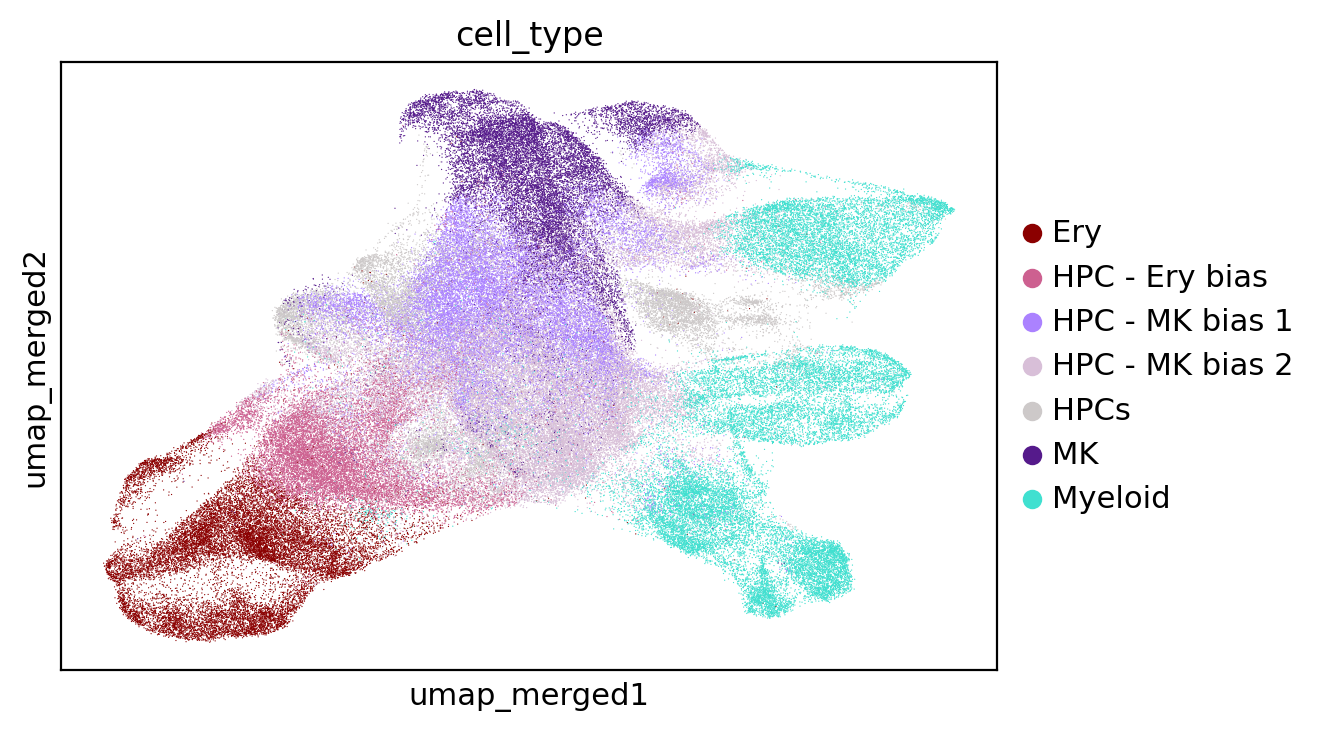

In [ ]:
cols = {"HPCs": "#cdc9c9", "HPC - MK bias 2": "thistle", "HPC - MK bias 1": "#ab82ff", "MK": "#551a8b",
        "HPC - Ery bias": "#cd6090", "Ery": "#8b0000", "Myeloid": "turquoise"}
sc.pl.embedding(
    adata,
    color=["cell_type"],
    basis="umap_merged",
    color_map="gnuplot2",
    palette=cols
)

In [ ]:
# plot umap to check
# sc.pl.umap(adata, color=["cell_type"], palette=cols, frameon=False) #save="timecourse-d7911-umap-adata-merged.pdf")

In [ ]:
# save merged dataset as anndata format
adata.write("../seurat_objects/timecourse-d7911-renamed-merged.h5ad")

In [ ]:
# reload dataset
adata = sc.read_h5ad("../seurat_objects/timecourse-d7911-renamed-merged.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'